# 🏦 Central Bank Speech Analysis with FinBERT
### Hawkish vs Dovish Tone Detection using Financial NLP Embeddings

This notebook leverages **FinBERT** (a BERT model fine-tuned on financial text) from HuggingFace to:
1. Embed central bank / Fed speeches
2. Summarize key findings from each speech
3. Classify the **hawkish / neutral / dovish** tone using cosine similarity against anchor phrases
4. Visualize results across speeches

---

## 1. Install & Import Dependencies

In [ ]:
%pip install transformers -q
%pip install torch -q
%pip install sentence_transformers -q
%pip install scikit-learn -q
%pip install matplotlib -q
%pip install seaborn -q

In [ ]:
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

print('All libraries loaded successfully')
print(f'\nPyTorch version: {torch.__version__}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

## 2. Load FinBERT Model

I use `ProsusAI/finbert` — a BERT model pre-trained on financial communications, press releases, and analyst reports. It understands the nuanced language of central banks far better than general-purpose models.

In [ ]:
MODEL_NAME = 'ProsusAI/finbert'

print(f'Loading tokenizer and model: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval() # Set model to evaluation mode for inference 
model.to(device)

print('\nFinBERT loaded successfully!')

## 3. Embedding Helper Function

FinBERT processes text in chunks (max 512 tokens). I use **mean pooling** over the last hidden state with attention masking, this is the standard approach for extracting sentence-level embeddings from BERT-based models.

In [ ]:
def mean_pooling(model_output, attention_mask):
    """
    Apply mean pooling to token embeddings, respecting the attention mask.
    
    Attention_mask: tells BERT which tokens are real (1) vs padding (0).
    I expand it to match the hidden state dimensions, then average only
    over the real (non-padding) tokens.
    """
    token_embeddings = model_output.last_hidden_state  # shape: (batch, seq_len, hidden_dim)
    
    # Expand mask from (batch, seq_len) → (batch, seq_len, hidden_dim)
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    
    # Sum embeddings for real tokens, divide by count of real tokens
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1) 
    # dim=1 --> compare the whole embedding vector for each token in the sequence, then sum across the sequence length dimension
    # dim=0 --> compare across sentences (batch dimension)

    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    
    return (sum_embeddings / sum_mask).detach().cpu().numpy()



def get_embedding(text: str) -> np.ndarray:
    """
    Tokenize text and return a single FinBERT embedding vector.
    Long texts are truncated to 512 tokens (BERT's max).
    """
    encoded = tokenizer(
        text,
        padding=True, # Add padding to ensure all sequences are 512 tokens long
        truncation=True,
        max_length=512,
        return_tensors='pt' # Return PyTorch tensors for model compatibility
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    # k: key, is the name of the input (e.g., 'input_ids', 'attention_mask'), 
    # v: value,  is the corresponding tensor moved to the appropriate device (CPU or GPU)
    
    with torch.no_grad():
        output = model(**encoded)
    
    return mean_pooling(output, encoded['attention_mask'])


def get_embeddings_batch(texts: list) -> np.ndarray:
    """Embed a list of texts and return stacked numpy array."""
    return np.vstack([get_embedding(t) for t in texts])

## 4. Central Bank Speech Dataset

Five real excerpts from major central bank communications (Fed, ECB, BOE, BOJ, RBA), covering a range of monetary policy stances.

In [ ]:
# ============================================================
# CENTRAL BANK SPEECH INPUT  
# JSON-like format — update 'text' fields with your own excerpts
# ============================================================

speeches = [
    {
        "id": "S1",
        "source": "Federal Reserve (Jerome Powell)",
        "date": "2026-01-28",
        "event": "FOMC Press Conference",
        "text": (
            "Good afternoon. My colleagues and I remain squarely focused on achieving our dual-mandate goals of maximum employment and stable prices for the benefit of the American people. "
            "The U.S. economy expanded at a solid pace last year and is coming into 2026 on a firm footing. While job gains have remained low, the unemployment rate has shown some signs of stabilization, and inflation remains somewhat elevated. "
            "In support of our goals, today the Federal Open Market Committee decided to leave our policy rate unchanged. Having lowered our policy rate by 75 basis points over the course of our previous three meetings, we see the current stance of monetary policy as appropriate to promote progress toward both our maximum-employment and 2 percent inflation goals. "
            "I will have more to say about monetary policy after briefly reviewing economic developments. Available indicators suggest that economic activity has been expanding at a solid pace. Consumer spending has been resilient, and business fixed investment has continued to expand. "
            "In contrast, activity in the housing sector has remained weak. The temporary shutdown of the federal government likely weighed on economic activity last quarter, but these effects should be reversed as the reopening boosts growth this quarter. "
            "In the labor market, indicators suggest that conditions may be stabilizing after a period of gradual softening. The unemployment rate was 4.4 percent in December and has changed little in recent months. Job gains have remained low. Total nonfarm payrolls declined at an average pace of 22,000 per month over the last three months; excluding government employment, private payrolls rose at an average pace of 29,000 per month. "
            "A good part of the slowing in the pace of job growth over the past year reflects a decline in the growth of the labor force due to lower immigration and labor force participation, though labor demand has clearly softened as well. "
            "Other indicators, including openings, layoffs, hiring, and nominal wage growth, show little change in recent months. Inflation has eased significantly from its highs in mid-2022 but remains somewhat elevated relative to our 2 percent longer-run goal. "
            "Estimates based on the consumer price index indicate that total PCE prices rose 2.9 percent over the 12 months ending in December and that, excluding the volatile food and energy categories, core PCE prices rose 3.0 percent. These elevated readings largely reflect inflation in the goods sector, which has been boosted by the effects of tariffs. "
            "In contrast, disinflation appears to be continuing in the services sector. Near-term measures of inflation expectations have declined from last year’s peaks, as reflected in both market- and survey-based measures. Most measures of longer-term expectations remain consistent with our 2 percent inflation goal. "
            "Our monetary policy actions are guided by our dual mandate to promote maximum employment and stable prices for the American people. At today’s meeting, the Committee decided to maintain the target range for the federal funds rate at 3½ to 3¾ percent. Since last September, we have lowered our policy rate 75 basis points, or ¾ of a percentage point, bringing it within a range of plausible estimates of neutral. "
            "This normalization of our policy stance should help stabilize the labor market while allowing inflation to resume its downward trend toward 2 percent once the effects of tariff increases have passed through. We are well positioned to determine the extent and timing of additional adjustments to our policy rate based on the incoming data, the evolving outlook, and the balance of risks. Monetary policy is not on a preset course, and we will make our decisions on a meeting-by-meeting basis."
        )
    },
    {
        "id": "S2",
        "source": "European Central Bank (Christine Lagarde)",
        "date": "2026-02-26",
        "event": "Hearing of the Committee on Economic and Monetary Affairs of the European Parliament",
        "text": (
            "The economy is estimated to have grown by 0.3% in the fourth quarter of last year and by 1.5% in 2025 as a whole – better than what was projected for 2025 at the start of that year. "
            "Growth in the fourth quarter was primarily driven by domestic demand, with services activity – especially in the information and communication sector – playing a key role. Manufacturing has been weaker, but overall still resilient to the impact of higher tariffs and geopolitical uncertainty, while construction is gradually gaining momentum. "
            "In the period ahead, activity is expected to be supported by rising labour income amid a resilient labour market, as well as investment in defence, infrastructure and digital technologies. At the same time, the trade environment remains challenging owing to higher tariffs, a stronger euro and a persistently volatile global policy environment. "
            "Inflation declined to 1.7% in January, from 2.0% in December, owing to lower energy and services inflation. Core inflation – excluding energy and food – eased to 2.2%, after 2.3% in December. "
            "With inflation lower than nominal wage growth, real wages – wages that are adjusted for inflation – have not only recovered but have on average risen above levels seen in early 2021. Wage growth remains elevated but has eased gradually and is expected to continue to moderate to around 3% in the medium term. "
            "We continue to expect inflation to stabilise at our 2% target in the medium term. We therefore decided to keep the three key ECB interest rates unchanged at our monetary policy meeting earlier this month. "
            "Looking ahead, we will continue to follow a data-dependent and meeting-by-meeting approach to determining the appropriate monetary policy stance. In particular, our interest rate decisions will be based on our assessment of the inflation outlook and the risks surrounding it, in light of the incoming economic and financial data, as well as the dynamics of underlying inflation and the strength of monetary policy transmission. We are not pre-committing to a particular interest rate path."
        )
    },
    {
        "id": "S3",
        "source": "Bank of England (Andrew Bailey)",
        "date": "2026-02-08",
        "event": "AlUla Conference for Emerging Market Economies 2026",
        "text": (
            "I will start by drawing out the key points from the latest update of the IMF World Economic Outlook. The good news is that the world economy has been remarkably resilient in the face of much higher policy uncertainty. Although this uncertainty, including the impact of tariffs, has weighed on the level of activity, and accepting that there is varying momentum of economic activity across countries and sectors, the world economy has shown an impressive ability to adapt to the shifting landscape. Inflation has not risen markedly in the last year, though the cost of living (which is an issue of price levels relative to income levels) remains an important concern in quite a few countries. "
            "Alongside this resilience of the world economy, global financial conditions have been accommodative, despite episodes of volatility and rising sovereign yields. An important part of this story has been equity valuations in the technology sector, and particularly in the AI part. "
            "Overall, market conditions could have been much worse given the backdrop. That they have not been so reflects I think a number of factors at work. First, markets have become cautious in their reactions since not all of the initial announcements of policy shifts have been followed through to the word, and on occasions the impact of the announcement on economies and financial markets has not been as initially predicted. Second, markets are cautious to trade geopolitical risk when some of the traditional safe haven assets are close to the epicentre of the risks themselves and exhibit close correlations to risky assets, thus negating the safe-haven protection. Third, we have seen evidence of fear of missing out, backed by arguments along the lines of this time is different, for instance because of the expected productivity benefits of AI. The net result is a risk of some complacency in financial markets. "
            "The IMF caution in their update that risks to the world economic outlook are tilted to the downside. Four reasons for this can be drawn out. First, there could be a significant escalation of geopolitical tensions. Second, and closely aligned, there could be further disruption to the fragile balance of trade policy. Third, fiscal vulnerabilities could emerge against a context of elevated public debt levels. And fourth, expectations of AI driven productivity gains could be disappointed. "
            "I think this summary from the latest WEO fairly describes the current state of the world economy and the risks."
        )
    },
    {
        "id": "S4",
        "source": "Bank of Japan (Kazuo Ueda)",
        "date": "2025-12-25",
        "event": "Meeting of Councillors of Keidanren (Toward the Achievement of the Price Stability Target Accompanied by Wage Increases)",
        "text": (
            "Let me start by talking about recent developments in economic activity and prices and the Bank's conduct of monetary policy. In March 2024, the Bank judged it was within sight that the price stability target of 2 percent would be achieved in a sustainable and stable manner, and changed its large-scale monetary easing framework, which had lasted for over a decade. The Bank thereby shifted its monetary policy to guiding the short-term interest rate as a primary policy tool. Against this backdrop, the Bank gradually adjusted the degree of monetary accommodation by raising the policy interest rate to around 0.25 percent in July 2024 and to around 0.5 percent in January 2025. "
            "Thereafter, with uncertainties regarding U.S. tariff policies remaining high, the Bank kept the policy interest rate unchanged. At last week's MPM, however, it decided to raise the policy interest rate from around 0.5 percent to around 0.75 percent. In making this decision, the key factors were developments in the U.S. economy and the impact of tariff policies as well as moves to raise wages in light of next year's annual spring labor-management wage negotiations. "
            "First, as for the U.S. economy and the impact of tariff policies, the Bank judged that, while uncertainties remained, they had declined. Looking at the U.S. economy, with the pass-through of tariff costs to selling prices remaining only moderate, private consumption has been solid. Moreover, business fixed investment has increased, reflecting an expansion in AI-related demand. In light of these developments, while there are still factors to consider, such as developments in the labor market, it appears that downside risks to the U.S. economy overall have decreased. With regard to the impact of tariff policies on Japan's economy, although there has been downward pressure on corporate profits, mainly in manufacturing, there are no signs that the effects have spread to the economy as a whole, including business fixed investment and employment and wage developments. Please take a look at Chart 1. The *Tankan* (Short-Term Economic Survey of Enterprises in Japan) released last week indicates that business sentiment, shown in the left panel, has been at a favorable level. Regarding corporate profits shown in the right panel, profit projections for fiscal 2025 have been revised upward slightly from the projections in the previous survey released three months ago, including in manufacturing, suggesting that the uncertainty surrounding the outlook is gradually diminishing. "
            "Looking at the background conditions of wage developments, labor market conditions have continued to be tight, and corporate profits are expected to remain at high levels on the whole, even after taking into account the impact of tariff policies, as I mentioned earlier. In this situation, considering factors such as the stances of labor and management on the annual spring labor-management wage negotiations and anecdotal information gathered through the Bank's Head Office and branches, as shown in Chart 2, it is highly likely that firms will continue to raise wages steadily next year, following the solid wage increases this year, and the risk of firms' active wage-setting behavior being interrupted is expected to be low. On the price front, underlying CPI inflation has continued to rise moderately, with moves to pass on wage increases to selling prices continuing. "
            "Based on these recent data and anecdotal information, it is highly likely that the mechanism in which both wages and prices rise moderately will be maintained next year and beyond. As a result, it appears that the likelihood of realizing the Bank's baseline scenario has been rising -- that is, underlying CPI inflation will be at a level that is generally consistent with the price stability target of 2 percent in the second half of the projection period of the October 2025 *Outlook for Economic Activity and Prices* (Outlook Report), which extends from the second half of fiscal 2026 through fiscal 2027. In view of these developments in economic activity and prices, the Bank, at the MPM held last week, judged it appropriate to raise the policy interest rate and adjust the degree of monetary accommodation from the perspective of sustainable and stable achievement of the price stability target of 2 percent. "
            "As for the future conduct of monetary policy, given that real interest rates are at significantly low levels, if the baseline scenario presented in the October Outlook Report is realized, the Bank, in accordance with improvement in economic activity and prices, will continue to raise the policy interest rate and adjust the degree of monetary accommodation. The Bank believes that adjusting the degree of monetary accommodation as appropriate will lead to smoothly achieving the price stability target and to long-term growth that can serve as a foundation for firms to conduct business with confidence."
        )
    },
    {
        "id": "S5",
        "source": "Reserve Bank of Australia (Michele Bullock)",
        "date": "2026-03-03",
        "event": "The Australian Financial Review Business Summit",
        "text": (
            "Since the middle of last year, inflationary pressures have picked up, partly because capacity pressures have been stronger than we previously assessed. With underlying inflation now expected to enter the 2–3 per cent range in mid-2027 and the labour market still somewhat tight, the Board was unanimous in its decision to raise the cash rate in February. "
            "Today I will set out why the Board judged a rate rise to be necessary in February, how it supports our monetary policy strategy, and how we make decisions even when uncertainty is elevated. I also want to explain why listening directly to Australian households and businesses is an essential input to our decision-making. "
            "Inflation is too high and monetary policy needed to respond. In the statement following its decision in February, and in the subsequent minutes of the meeting, the Board noted that inflation is too high and that some of the recent increase in inflation is likely to persist (Graph 1). Staff forecasts did not see inflation coming back into the target band until mid-2027 – that is over a year away. The staff’s view is that the CPI data for January, which was released after the February meeting, broadly supports this assessment. Headline inflation was 3.8 per cent in the year to January and it will continue to be boosted for a time by the unwinding of electricity rebates. But measures of underlying inflation, which strip out some of the large temporary price moves, are also above the top end of our 2–3 per cent target band. "
            "High inflation imposes real costs on people and the economy. It puts pressure on household budgets, which means people need to spend more time searching for the lowest prices and working out how to make ends meet. This can be stressful and can force some tough decisions. We don’t want families to have to cut back on after-school activities for their children or delay non-urgent medical care. And we certainly don’t want people to go without essentials. These are just some examples of the real costs of high inflation for all Australians that we are trying to avoid. "
            "High inflation also makes it harder for businesses to plan. When businesses have to spend more time managing rising costs, they have less time to plan how they can grow through investment and productivity improvements. Even when businesses have growth plans, high inflation creates uncertainty, and that can lead them to delay those plans. This is why low and stable inflation matters. It eases the strain on household budgets and creates the conditions businesses need to invest and lift productivity. "
            "We have spent a lot of time thinking about the recent increase in inflation and whether this will continue. Temporary factors have played a part, as my colleague Michael Plumb said in a speech last week. But we judge that some of the inflation pressures are because demand exceeds the economy’s supply capacity. Around six months ago we thought that demand and supply would soon be close to balance. But we now think demand was outstripping supply over the second half of last year. There are a few reasons for this. "
            "First, private demand has been stronger than we expected. Global conditions proved more resilient than many feared after the tariff announcements last year, and financial conditions have been more supportive of growth than anticipated. "
            "Second, the economy’s supply potential appears to have been somewhat lower than previously assessed. And with our updated judgement that underlying demand exceeds that supply potential, inflation is likely to remain above target until those pressures ease. That assessment was central to the Board’s decision to increase the cash rate last month. "
            "As you know, the Board looks closely at the labour market when making its decisions. Under our dual mandate, we aim not only to keep inflation low and stable but also to achieve full employment – which is the highest level of employment that is consistent with low and stable inflation. "
            "Last year we were concerned that there was a risk that the labour market could weaken materially. That has not happened – which is very welcome – and the labour market was resilient through 2025. In fact, recent labour market outcomes have come in stronger than we anticipated mid-last year, as my colleague Sarah Hunter highlighted in a speech a few weeks ago. Unemployment is still low, the vacancies-to-unemployment ratio is high, and growth in unit labour costs remains elevated (Graph 2). "
            "While we expect labour market conditions to ease over time as the economy comes back into balance, we still assess that it is somewhat tight overall. Our judgement in February was that capacity pressures – in the labour market and the economy more broadly – contributed to the recent increase in inflation, and that it was appropriate to tighten policy. The danger we faced was that leaving interest rates unchanged would risk having inflation above target for longer, ultimately requiring a more aggressive tightening later, and a more costly adjustment in the labour market."
        )
    }
]

print(f'Loaded {len(speeches)} central bank speeches:')
for s in speeches:
    print(f"  [{s['id']}] {s['source']} — {s['date']}")

## 5. Define Hawkish / Neutral / Dovish Anchor Phrases

I embed **anchor phrases** that represent each monetary policy stance. A speech's tone is classified by computing cosine similarity between its embedding and each anchor's embedding — the closest anchor wins.

This is a **zero-shot classification** approach using semantic similarity — no labeled training data needed.

In [ ]:
# Anchor phrases representing each monetary policy stance
anchors = {
    "Hawkish": (
        "We are raising interest rates to combat inflation. "
        "Further rate hikes are necessary. Inflation is too high and we must tighten policy. "
        "We are not considering rate cuts. Restrictive policy must be maintained."
    ),
    "Neutral": (
        "We are holding rates steady and watching incoming data. "
        "We are neither tightening nor easing. Policy is on hold. "
        "We will decide meeting by meeting with no preset direction."
    ),
    "Dovish": (
        "We are cutting interest rates to support growth and employment. "
        "Accommodative policy will continue. We are easing financial conditions. "
        "Rate cuts are appropriate given the weakening economy."
    )
}

print('Anchor stances defined:')
for stance, text in anchors.items():
    print(f'  {stance}: "{text[:80]}..."')

## 6. Generate Embeddings

In [ ]:
print('Embedding anchor phrases...')
anchor_labels = list(anchors.keys())
anchor_texts  = list(anchors.values())
anchor_embeddings = get_embeddings_batch(anchor_texts)   # shape: (3, 768) --> 3 stances, 768-dim embeddings
print(f'  Anchor embedding shape: {anchor_embeddings.shape}')

print('\nEmbedding central bank speeches...')
speech_texts      = [s['text'] for s in speeches]
speech_embeddings = get_embeddings_batch(speech_texts)   # shape: (5, 768)
print(f'  Speech embedding shape: {speech_embeddings.shape}')

print('\nAll embeddings generated!')

Embedding anchor phrases...
  Anchor embedding shape: (3, 768)

Embedding central bank speeches...
  Speech embedding shape: (5, 768)

All embeddings generated!


## 7. Classify Tone & Summarize Key Findings

In [ ]:
# Compute cosine similarity: speeches × anchors  →  shape (5, 3)
sim_matrix = cosine_similarity(speech_embeddings, anchor_embeddings)

# Rule-based keyword extractor for key findings summary
def extract_key_findings(text: str) -> list:
    """
    Extract the most informative sentences from a speech excerpt.
    Scores sentences by presence of high-signal monetary policy keywords.
    """
    keywords = [
        "decided to", "judged", "Board", "policy rate", "Bank rate", "cash rate", 
        "interest rate", "leave", "keep", "unchanged", "raise", "increase", "lower", 
        "reduce", "appropriate", "necessary", "normalisation"
    ]


    sentences = [s.strip() for s in text.replace('\n', ' ').split('.') if len(s.strip()) > 30] 
    scored = []
    for sent in sentences:
        score = sum(1 for kw in keywords if kw.lower() in sent.lower()) #counts the number of keywords in the sentence and assigns a score based on that count
        scored.append((score, sent))
    scored.sort(reverse=True)
    #return [s for _, s in scored[:3]]   # top 3 sentences without marks showing up
    return [f"(Score: {marks}): {s}" for marks, s in scored[:5]]   # top 5 sentences with marks


# ============================================================
# RESULTS TABLE
# ============================================================
results = []

print('=' * 80)
print('CENTRAL BANK SPEECH ANALYSIS — FinBERT Hawkish/Dovish Classification')
print('=' * 80)

for i, speech in enumerate(speeches):
    scores        = sim_matrix[i]                        # similarity to each anchor
    best_idx      = int(np.argmax(scores))               # index of the anchor with highest similarity score
    tone          = anchor_labels[best_idx]              # label of the anchor with highest similarity score (Hawkish, Neutral, Dovish)
    confidence    = float(scores[best_idx])              # similarity score of the best matching anchor, indicating how closely the speech aligns with that stance
    hawk_score    = float(scores[0])
    neutral_score = float(scores[1])
    dove_score    = float(scores[2])
    key_findings  = extract_key_findings(speech['text'])  # Extract key findings from speech text instead of summary, 
                                                           # as the summary may not contain the most important information

    results.append({
        **speech,
        'tone'          : tone,
        'confidence'    : confidence,
        'hawk_score'    : hawk_score,
        'neutral_score' : neutral_score,
        'dove_score'    : dove_score,
        'key_findings'  : key_findings
    })

    tone_icon = {'Hawkish': '🦅', 'Neutral': '⚖️', 'Dovish': '🕊️'}[tone]

    print(f"\n[{speech['id']}] {speech['source']}")
    print(f"       Date  : {speech['date']} | Event: {speech['event']}")
    print(f"       Tone  : {tone_icon} {tone}  (confidence: {confidence:.4f})")
    print(f"       Scores: Hawkish={hawk_score:.4f}  |  Neutral={neutral_score:.4f}  |  Dovish={dove_score:.4f}")
    print(f"       Key Findings:")
    for j, finding in enumerate(key_findings, 1):
        print(f"         {j}. {finding.strip()}.")

print('\n' + '=' * 80)

CENTRAL BANK SPEECH ANALYSIS — FinBERT Hawkish/Dovish Classification

[S1] Federal Reserve (Jerome Powell)
       Date  : 2026-01-28 | Event: FOMC Press Conference
       Tone  : 🕊️ Dovish  (confidence: 0.7639)
       Scores: Hawkish=0.6748  |  Neutral=0.6170  |  Dovish=0.7639
       Key Findings:
         1. (Score: 4): In support of our goals, today the Federal Open Market Committee decided to leave our policy rate unchanged.
         2. (Score: 3): Having lowered our policy rate by 75 basis points over the course of our previous three meetings, we see the current stance of monetary policy as appropriate to promote progress toward both our maximum-employment and 2 percent inflation goals.
         3. (Score: 2): Since last September, we have lowered our policy rate 75 basis points, or ¾ of a percentage point, bringing it within a range of plausible estimates of neutral.
         4. (Score: 1): We are well positioned to determine the extent and timing of additional adjustments to our 

## 8. Visualizations

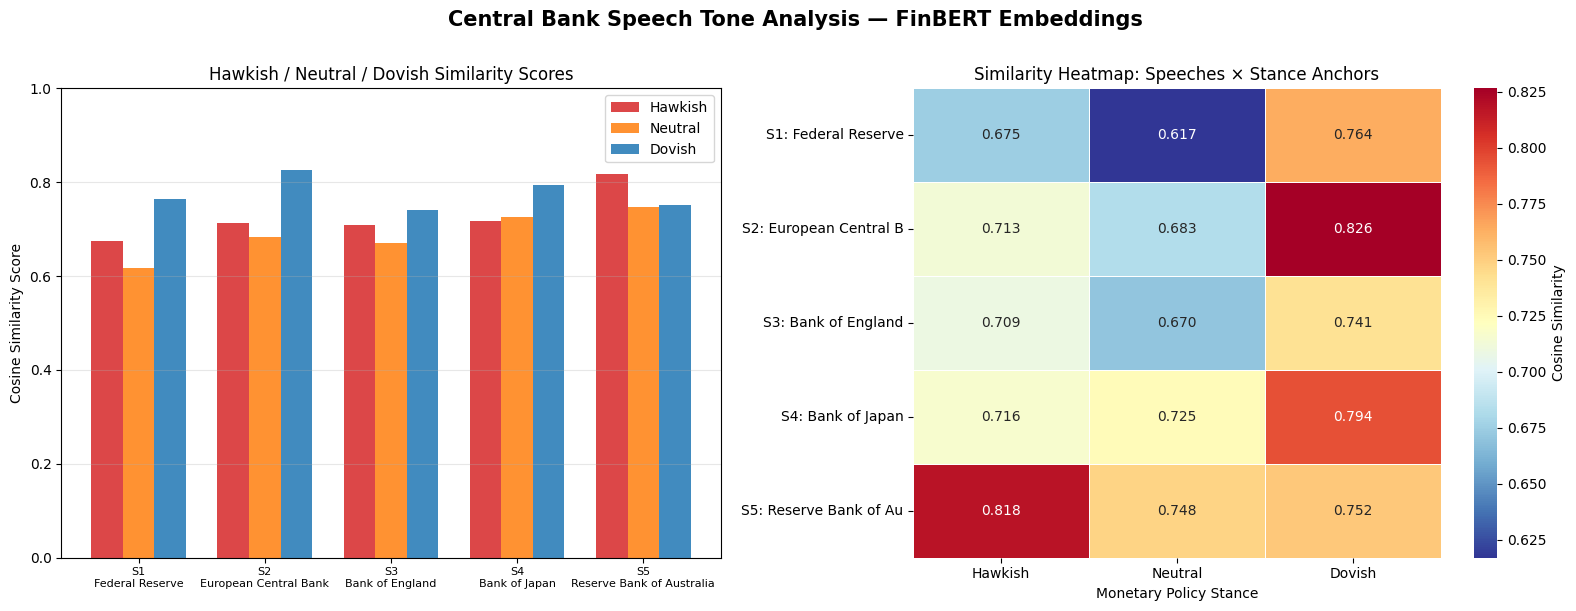

Chart saved as speech_tone_analysis.png


In [ ]:
# ── Chart setup ────────────────────────────────────────────────────────────────
TONE_COLORS = {'Hawkish': '#d62728', 'Neutral': '#ff7f0e', 'Dovish': '#1f77b4'}
labels      = [f"{r['id']}\n{r['source'].split('(')[0].strip()}" for r in results]
hawk_vals   = [r['hawk_score']    for r in results]
neut_vals   = [r['neutral_score'] for r in results]
dove_vals   = [r['dove_score']    for r in results]
tones       = [r['tone']         for r in results]
bar_colors  = [TONE_COLORS[t]    for t in tones]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Central Bank Speech Tone Analysis — FinBERT Embeddings', 
             fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: Grouped bar chart ──────────────────────────────────────────────────
ax1  = axes[0]
x    = np.arange(len(results))
w    = 0.25

ax1.bar(x - w, hawk_vals, width=w, color='#d62728', alpha=0.85, label='Hawkish')
ax1.bar(x,     neut_vals, width=w, color='#ff7f0e', alpha=0.85, label='Neutral')
ax1.bar(x + w, dove_vals, width=w, color='#1f77b4', alpha=0.85, label='Dovish')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylabel('Cosine Similarity Score')
ax1.set_title('Hawkish / Neutral / Dovish Similarity Scores')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# ── Plot 2: Heatmap of similarity matrix ──────────────────────────────────────
ax2  = axes[1]
short_labels = [f"{r['id']}: {r['source'].split('(')[0].strip()[:18]}" for r in results]

sns.heatmap(
    sim_matrix,
    ax=ax2,
    annot=True, fmt='.3f',
    cmap='RdYlBu_r',
    xticklabels=anchor_labels,
    yticklabels=short_labels,
    cbar_kws={'label': 'Cosine Similarity'},
    linewidths=0.5
)
ax2.set_title('Similarity Heatmap: Speeches × Stance Anchors')
ax2.set_xlabel('Monetary Policy Stance')

plt.tight_layout()
plt.savefig('speech_tone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as speech_tone_analysis.png')

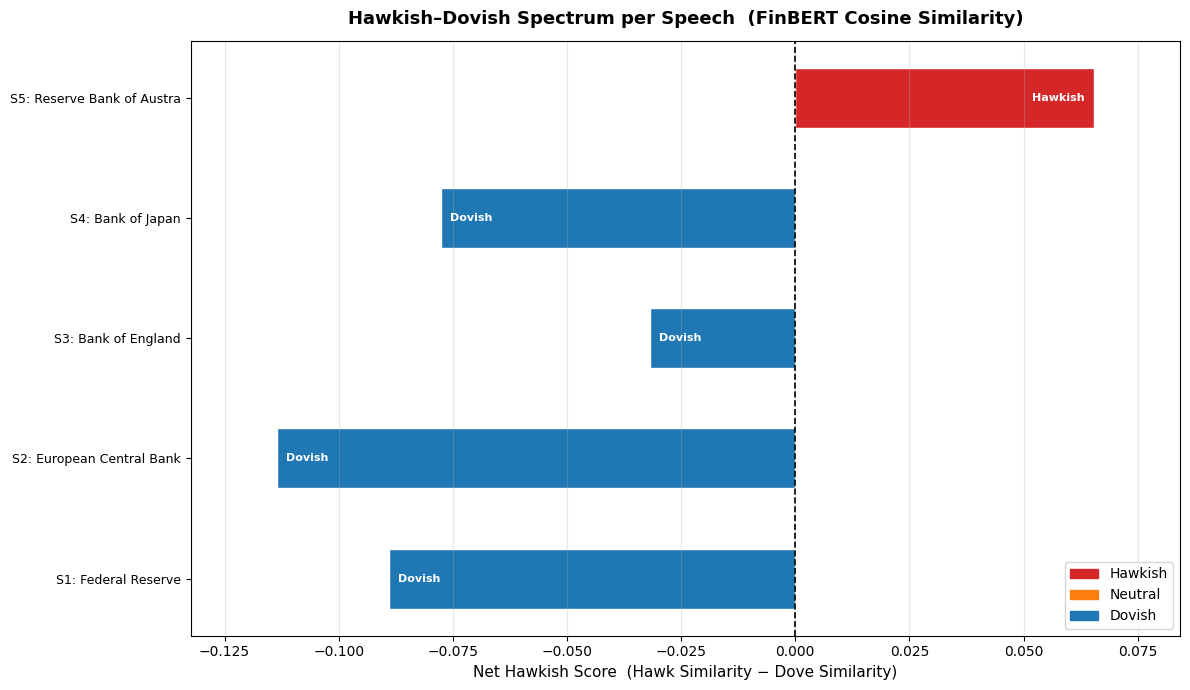

📊 Spectrum chart saved as hawk_dove_spectrum.png


In [12]:
# ── Plot 3: Hawkish-Dovish Spectrum ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Net hawk score: positive = hawkish, negative = dovish
net_scores = [r['hawk_score'] - r['dove_score'] for r in results]
# Y-axis labels: ID + shortened source name, kept to a fixed width
y_labels   = [f"{r['id']}: {r['source'].split('(')[0].strip()[:22]}" for r in results]
colors     = ['#d62728' if s > 0.01 else ('#1f77b4' if s < -0.01 else '#ff7f0e') for s in net_scores]

bars = ax.barh(y_labels, net_scores, color=colors, edgecolor='white', height=0.5)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Net Hawkish Score  (Hawk Similarity − Dove Similarity)', fontsize=11)
ax.set_title('Hawkish–Dovish Spectrum per Speech  (FinBERT Cosine Similarity)',
             fontsize=13, fontweight='bold', pad=12)

# ── Annotate INSIDE each bar so labels never overflow ──────────────────────────
for bar, r in zip(bars, results):
    width  = bar.get_width()
    cy     = bar.get_y() + bar.get_height() / 2
    tone   = r['tone']
    label  = f"{tone}"
    # place text just inside the bar end
    if width >= 0:
        ax.text(width - 0.002, cy, label, va='center', ha='right',
                fontsize=8, color='white', fontweight='bold')
    else:
        ax.text(width + 0.002, cy, label, va='center', ha='left',
                fontsize=8, color='white', fontweight='bold')

# Add breathing room on both sides so nothing clips
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - 0.01, x_max + 0.01)

hawk_patch = mpatches.Patch(color='#d62728', label='Hawkish')
neut_patch = mpatches.Patch(color='#ff7f0e', label='Neutral')
dove_patch = mpatches.Patch(color='#1f77b4', label='Dovish')
ax.legend(handles=[hawk_patch, neut_patch, dove_patch], loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('hawk_dove_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Spectrum chart saved as hawk_dove_spectrum.png')

## 10. Cross-Speech Semantic Similarity

How similar are the speeches to each other? This shows which central banks are communicating similarly.

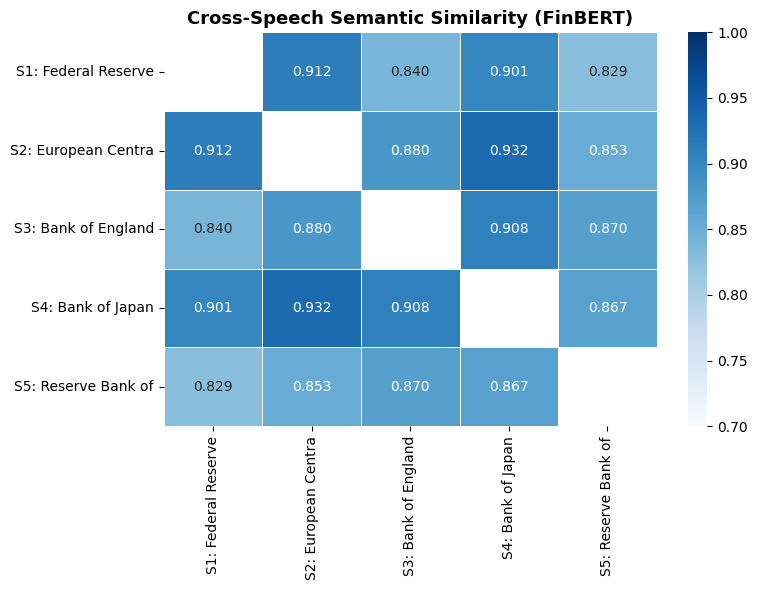

Cross-speech similarity chart saved


In [14]:
# Pairwise similarity between all speeches
speech_sim_matrix = cosine_similarity(speech_embeddings, speech_embeddings)

speech_short_labels = [f"{r['id']}: {r['source'].split('(')[0].strip()[:15]}" for r in results]

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.eye(len(results), dtype=bool)   # hide diagonal (self-similarity = 1.0)

sns.heatmap(
    speech_sim_matrix,
    ax=ax,
    annot=True, fmt='.3f',
    cmap='Blues',
    mask=mask,
    xticklabels=speech_short_labels,
    yticklabels=speech_short_labels,
    vmin=0.7, vmax=1.0,
    linewidths=0.5
)

ax.set_title('Cross-Speech Semantic Similarity (FinBERT)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_speech_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cross-speech similarity chart saved')

---

**Key takeaways:**
- FinBERT's financial domain pre-training captures monetary policy language far better than general-purpose BERT
- Zero-shot classification via anchor similarity requires no labeled data — useful for rapidly prototyping research tools
- This pipeline can be extended with: (1) LLM-generated summaries, (2) time-series tracking of tone shifts, (3) cross-asset signal generation

---
*Built with ProsusAI/FinBERT · HuggingFace Transformers · PyTorch*